# STAT 207 Homework 3 [25 points]

## Populations, Samples, and Summarizing Data

Due: Monday, February 16, end of day (11:59 pm CT)

Late Submissions accepted until Friday, February 17 at noon

<hr>

## Purpose

The Olympics is a worldwide event where athletes from multiple sports all compete in one meet.  Top athletes prepare for months to make history with their athletic prowess.  

Information about athletes that have competed in the Olympics are contained in the athlete_events.csv file located in this folder (originally from https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results).

Each competitor in a distinct Olympic competition is displayed in their own row in the data.  That is, the unit of observation is a combination of the athlete, Olympic meet (summer/winter and year), and event.

You are interested in summarizing the characteristics and results of the athletes who compete in the Olympics, to know more about the typical athlete and to share the results of these competitions.

## Python Component

Run the following code chunk to import the pandas package needed for this assignment and the optional visualization packages:

- pandas
- matplotlib.pyplot
- seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 1. Read in the Data [0.5 points]

**a)** Read the athlete_events.csv file in.  No need to search for missing values not immediately recognized by Python, and no need to drop any missing values.

In [3]:
df = pd.read_csv('athlete_events.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


**b)** Extra Gradescope Calculations

I'd suggest turning to Q1 on Gradescope here.

You'll likely need to further explore the data for Gradescope Q1.  You can use this section for any exploration that you'd like, although there are no points associated with this part.

In [4]:
df.shape

(271116, 15)

In [5]:
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [10]:
df['NOC'].value_counts()

NOC
USA    18853
FRA    12758
GBR    12256
ITA    10715
GER     9830
       ...  
YMD        5
SSD        3
UNK        2
NBO        2
NFL        1
Name: count, Length: 230, dtype: int64

In [11]:
x = df['Medal'].isna().sum()/len(df)
x

np.float64(0.853262072323286)

In [19]:
df[['Name']].value_counts()
df[df['Name'] == 'Robert Tait McKenzie'].head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
154798,77710,Robert Tait McKenzie,M,44.0,NaN,NaN,Canada,CAN,1912 Summer,1912,Summer,Stockholm,Art Competitions,Art Competitions Mixed Sculpturing,NaN
154799,77710,Robert Tait McKenzie,M,60.0,NaN,NaN,Canada,CAN,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN
154800,77710,Robert Tait McKenzie,M,60.0,NaN,NaN,Canada,CAN,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN
154801,77710,Robert Tait McKenzie,M,60.0,NaN,NaN,Canada,CAN,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN
154802,77710,Robert Tait McKenzie,M,60.0,NaN,NaN,Canada,CAN,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN


In [21]:
df['Year'].agg(['min', 'max'])

min    1896
max    2016
Name: Year, dtype: int64

## 2. Populations and Samples [0 points]

Extra Gradescope Calculations

I'd suggest continuing with Q2 on Gradescope here.

You may need to further explore the data for Gradescope Q2.  You can use this section for any exploration that you'd like, although there are no points associated with this coding part.  All points for Question 2 will come from Gradescope.

In [25]:
y = len(df[df['NOC'] == 'USA'])/len(df)
y

0.06953850012540758

## 3. Exploring Athlete Weights [2 points]

**a)** First, generate a graphical summary (histogram or boxplot) of the weight (`Weight`) variable.

array([[<Axes: title={'center': 'Weight'}>]], dtype=object)

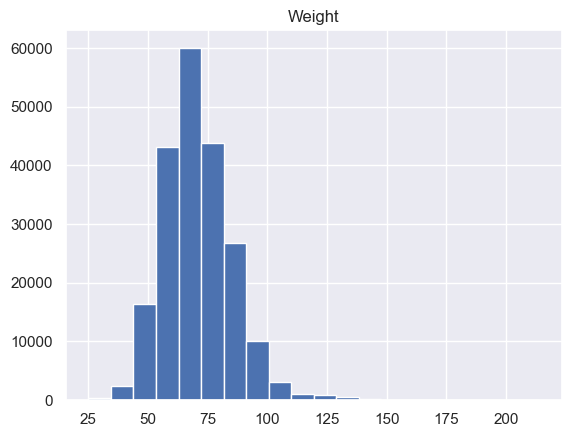

In [26]:
df.hist(column='Weight', bins=20)

**b)** We'd like to explore the weight of athletes (`Weight`) depending on the season of the competition (`Season`).  For each `Season`, generate a set of numerical summaries for `Weight`.  For full credit, do so in one line of code.

For the numerical summaries, be sure that both the mean and the median are included.

In [27]:
df.groupby("Season")["Weight"].agg(["count","mean","median","std","min","max"])


,count,mean,median,std,min,max
Season,,,,,,
Summer,168698,70.689060,70.0,14.803940,25.0,214.0
Winter,39543,70.759275,70.0,12.213273,32.0,145.0


**c)** Extra Gradescope Calculations

I'd suggest turning to Q3 on Gradescope here, using the results from parts **a** and **b** above.

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

In [29]:
df['Weight'].agg(['mean','median','min','max'])

mean       70.702393
median     70.000000
min        25.000000
max       214.000000
Name: Weight, dtype: float64

## 4. Two Way Table [1 point]

**a)** Generate a two-way table to summarize the medal color (`Medal`) with the season of competition (`Season`).  You may choose whether you'd like counts or proportions displayed.

In [30]:
pd.crosstab(df['Season'], df['Medal'], normalize='index')

Medal,Bronze,Gold,Silver
Season,,,
Summer,0.334693,0.336159,0.329148
Winter,0.331168,0.335909,0.332924


**b)** Extra Gradescope Calculations

I'd suggest turning to Q4 on Gradescope here, using the results from part **a** above.

You may need to further explore the data for Gradescope Q4.  You can use this section for any exploration that you'd like, although there are no points associated with this coding part.  

In [35]:
df_gold = df[df['Medal'] == 'Gold']
f = df_gold['ID'].nunique()
f/(df['ID'].nunique())

0.07689697649202264

## 5. Creating a Sample [2 points]

Now, we'll consider the heights of athletes (`Height`).

**a)** Take a random sample of 200 athletes from the data.  

In [36]:
sample_ids = df["ID"].drop_duplicates().sample(n=200)
df_200athletes = df[df["ID"].isin(sample_ids)]


**b)** Compare the heights of the 200 athletes from your random sample with the heights from the full data using at least one of numerical summaries or graphical displays.  You may choose how to compare these distributions.

In [39]:
v = df_200athletes['Height'].agg(['mean','median','min','max'])
v

mean      174.849624
median    176.000000
min       141.000000
max       208.000000
Name: Height, dtype: float64

In [38]:
c = df['Height'].agg(['mean','median','min','max'])
c

mean      175.33897
median    175.00000
min       127.00000
max       226.00000
Name: Height, dtype: float64

**c)** Extra Gradescope Calculations

I'd suggest turning to Q5 on Gradescope here, using the results from parts **a** and **b** above.

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

## 6. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

No ai was used

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

N/A

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 3 Canvas Assignment to submit your notebook to GitHub.  Be sure to also complete the Gradescope component of this assignment.